<a href="https://colab.research.google.com/github/chrispchen/ChenHypoxia/blob/main/scRNA-seq%20analysis/ComparecNMFwithPyDESeq2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compare cNMF and PyDESeq2

The goal here is to determine the extent to which the cNMF-identified GEP 5 is similar to the genes formally counted as differentially expressed across clusters by PyDESeq2

Importantly, cNMF and differential gene expression vary immensely in terms of statistics. For the number of genes present from cNMF, I arbitrarily chose 2000. To accomodate for this, I used gentle statistical cut offs in my differential gene expression tables. Also, the number of cells present in clusters compared via PyDESeq2 dramatically affects outputs, so I'm only using the top 6 most abundant clusters.

In [ ]:
!pip install matplotlib-venn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib_venn
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import glob
import os
import re


In [ ]:
GEPfull = pd.read_csv('/top_genes_k40.csv')
GEPfull

,Unnamed: 0,GEP_1,GEP_2,GEP_3,GEP_4,GEP_5,GEP_6,GEP_7,GEP_8,GEP_9,...,GEP_31,GEP_32,GEP_33,GEP_34,GEP_35,GEP_36,GEP_37,GEP_38,GEP_39,GEP_40
0,0,cxcr4b,foxi1,tbxta,sfrp1a,ppp1r15a,lmo4a,tiam1b,adgrl2a,efnb2a,...,tmtopsb,ppp1r9alb,emilin3a,ttn.2,bicc2,si:dkey-269i1.4,dlb,si:cabz01007794.1,krt5,dnd1
1,1,marcksl1b,tfap2a,eve1,otx1,tent5ba,rnf220a,rgs3b,FP565432.1,fscn1a,...,camk2d1,si:ch211-125o16.4,col8a1a,efemp2a,crocc2,calr3b,zgc:158291,atp10b,krt4,tdrd7a
2,2,ddx5,klf2b,dld,cyp26a1,mknk2b,hyal2b,si:ch211-151g22.1,znf1004,aplnrb,...,rapgef3,slc2a12,pmp22b,ttn.1,pkd1l1,si:dkey-239j18.2,elavl3,SAMD12,krt99,si:ch211-241j12.3
3,3,ctcf,dlx3b,hes6,otx2a,mcl1b,foxb1a,fgfr1b,jarid2b,efnb2b,...,card11,hsd17b12a,CR381618.1,mef2d,she,ctslb,onecutl,LOC100330916,krt8,nanos3
4,4,polr3gla,tfap2c,itgb5,plxdc2,pim2,chrd,slc38a3b,zgc:110796,trib3,...,fam19a5b,fa2h,sema5bb,myl10,syne1b,he1.1,tlx3b,slc35a3b,krt18a.1,si:ch211-241j12.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1995,ing2,si:ch211-155e24.3,selenot1b,RF01268,iqcc,pop7,yars2,si:ch73-103b11.2,tent5bb,...,CABZ01052570.1,cavin1a,pcdh2g10,sema7a,slc35b2,LOC101884161,apoc1,LOC110438534,bcap29,arpp19b
1996,1996,upf3b,CU695011.1,zgc:77486,zgc:172121,FO704721.2,BX649295.1,agla,metap1d,LOC101886161,...,ccdc167,ndr1,CU659670.1,CT027582.1,BX901883.2,XLOC_004994,ckmt2a,abhd17b,pdcd6ip,flii
1997,1997,miip,CABZ01102109.1,smu1a,znf644a,unm_hu7910,msl1b,si:ch73-335l21.1,si:ch73-1a9.4,cdh30,...,fuca2,fbxw11b,kctd12.1,CABZ01031870.1,dusp1,BX547939.1,man2b1,CABZ01079267.1,si:ch73-223f5.1,dcaf5
1998,1998,glrx,strada,gtf2a1,dctpp1,ptger4a,map3k3,MARF1,oclna,scarb2c,...,setd7,LOC110439407,zgc:153240,cope,cep104,taar20b,xkrx,ethe1,XLOC_039965,zgc:136254


In [ ]:
GEP5 = GEPfull['GEP_5'].to_list()
GEP5

['ppp1r15a',
 'tent5ba',
 'mknk2b',
 'mcl1b',
 'pim2',
 'pfkfb3',
 'zcchc2',
 'XLOC_010012',
 'pid1',
 'FQ323156.1',
 'znf395a',
 'ankrd37',
 'p4ha1b',
 'eno1a',
 'xpo1b',
 'stk35',
 'CR293507.1',
 'ldha',
 'nrbp2a',
 'wsb1',
 'egln2',
 'irs2a',
 'txnipa',
 'hif1an',
 'p4ha2',
 'ccng2',
 'odc1',
 'ddit4',
 'taok1a',
 'zgc:174224',
 'ranbp3a',
 'sptan1',
 'angptl4',
 'pcdh1b',
 'gapdhs',
 'insrb',
 'hsp90aa1.2',
 'slco2a1',
 'tnksa',
 'fbxl5',
 'rnf24',
 'xk',
 'si:ch211-117c9.5',
 'bach1a',
 'zgc:92606',
 'ptprsa',
 'map1lc3cl',
 'mthfr',
 'cacul1',
 'pfklb',
 'tiam1b',
 'RSBN1',
 'unkl',
 'isoc1',
 'trim35-7',
 'trir',
 'taf6',
 'tsc22d2',
 'arrdc3b',
 'si:dkey-85k7.7',
 'kdm5ba',
 'ube2c',
 'khnyn',
 'klf10',
 'atf7ip',
 'hsph1',
 'znf1154',
 'btg3',
 'aldocb',
 'pfkfb4a',
 'si:dkey-117m1.4',
 'phf21ab',
 'plod1a',
 'puf60a',
 'si:ch211-198m17.1',
 'pnp5b',
 'jade1',
 'tmem39b',
 'akt1s1',
 'tefb',
 'cited2',
 'slc38a3b',
 'bmpr1ab',
 'bbox1',
 'LOC100007686',
 'trrap',
 'ankrd11',
 

'Prechordal_plate' contains 1097 genes.
'Dorsal_margin' contains 2211 genes.
'EVL' contains 92 genes.
'Ectoderm_dorsal' contains 2434 genes.
'Ectoderm_ventral' contains 2287 genes.
'Endoderm' contains 717 genes.
'Forerunner_cells' contains 53 genes.
'Germline' contains 12 genes.
'Neural_plate_posterior' contains 10 genes.
'Non_dorsal_margin_involuted' contains 2443 genes.
'YSL' contains 3777 genes.

Plots saved to: /content/drive/MyDrive/Chris/All/Plots/


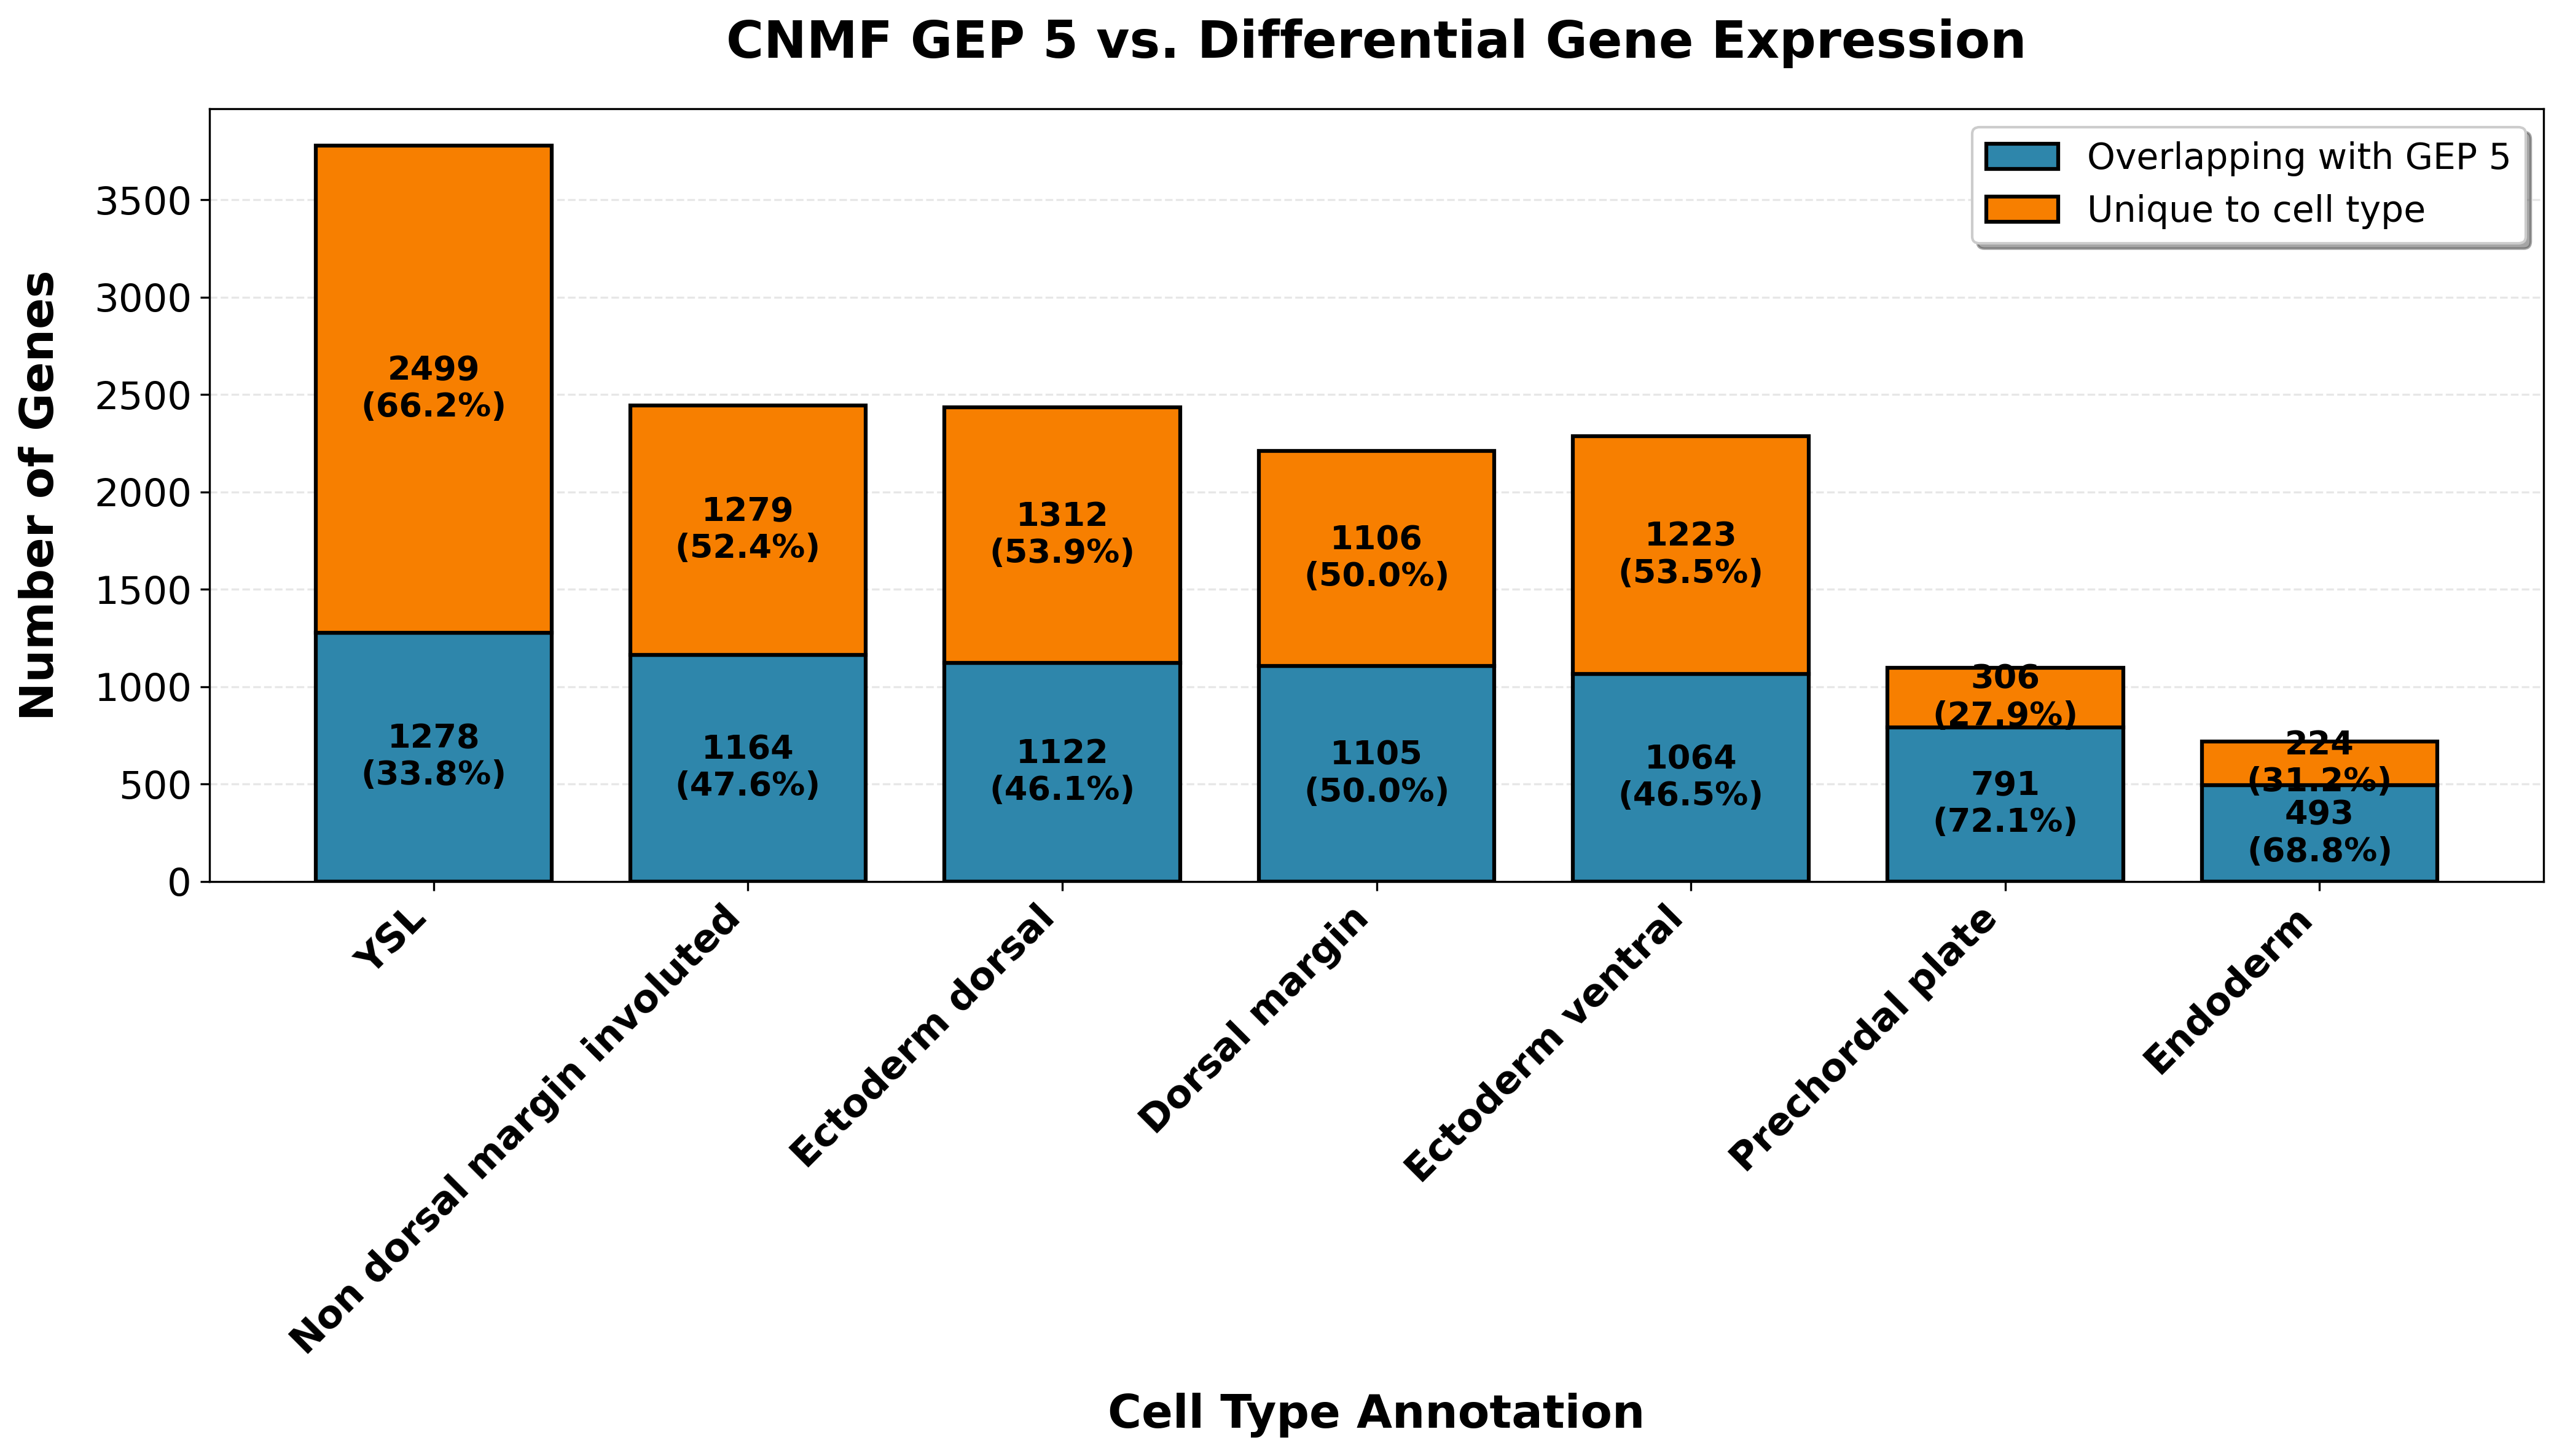


=== Summary Statistics (Sorted by Overlap) ===
Total genes in GEP5: 2000

YSL:
  Total DEGs: 3777
  Overlapping with GEP5: 1278 (33.8%)
  Unique to cell type: 2499

Non_dorsal_margin_involuted:
  Total DEGs: 2443
  Overlapping with GEP5: 1164 (47.6%)
  Unique to cell type: 1279

Ectoderm_dorsal:
  Total DEGs: 2434
  Overlapping with GEP5: 1122 (46.1%)
  Unique to cell type: 1312

Dorsal_margin:
  Total DEGs: 2211
  Overlapping with GEP5: 1105 (50.0%)
  Unique to cell type: 1106

Ectoderm_ventral:
  Total DEGs: 2287
  Overlapping with GEP5: 1064 (46.5%)
  Unique to cell type: 1223

Prechordal_plate:
  Total DEGs: 1097
  Overlapping with GEP5: 791 (72.1%)
  Unique to cell type: 306

Endoderm:
  Total DEGs: 717
  Overlapping with GEP5: 493 (68.8%)
  Unique to cell type: 224



In [ ]:


# Path to your CSV from pydeseq2
pathtocsvs = "/Hypoxia2hrsVs6hpf/"

# Get all CSV files in the path
csv_files = glob.glob(os.path.join(pathtocsvs, "*.csv"))

# Dictionary to store filtered gene lists
gene_lists = {}

# Loop through each CSV file
for file in csv_files:
    # Extract the last word from the filename (without extension)
    list_name = os.path.basename(file).split('_')[-1].replace('.csv', '')

    # Replace any characters that are invalid for variable names with underscores
    list_name = re.sub(r'\W|^(?=\d)', '_', list_name)

    # Read the CSV into a DataFrame
    df = pd.read_csv(file, index_col=0)

    # Filter genes based off of cut off
    filtered_genes = df[(df['padj'] < 0.05) & (df['log2FoldChange'] < -0.5)].index.tolist()

    # Only add to dictionary if it contains more than 1 gene
    if len(filtered_genes) > 1:
        gene_lists[list_name] = filtered_genes
        print(f"'{list_name}' contains {len(filtered_genes)} genes.")

# Select only the 6 specific cell types you want
lists = {
    'Dorsal_margin': gene_lists.get('Dorsal_margin', []),
    'Ectoderm_dorsal': gene_lists.get('Ectoderm_dorsal', []),
    'Ectoderm_ventral': gene_lists.get('Ectoderm_ventral', []),
    'Endoderm': gene_lists.get('Endoderm', []),
    'Non_dorsal_margin_involuted': gene_lists.get('Non_dorsal_margin_involuted', []),
    'YSL': gene_lists.get('YSL', []),
    'Prechordal_plate': gene_lists.get('Prechordal_plate', [])
}

# Define your GEP5 list here
GEP5 = GEPfull['GEP_5'].to_list()

# Convert GEP5 to set
set_GEP5 = set(GEP5)

# Calculate overlaps and unique genes for each cell type
data_for_sorting = []

for name, gene_list in lists.items():
    set_genes = set(gene_list)
    overlap = set_GEP5.intersection(set_genes)
    unique = set_genes - set_GEP5

    data_for_sorting.append({
        'name': name,
        'category': name.replace('_', ' '),
        'overlap': len(overlap),
        'unique': len(unique)
    })

# Sort by overlapping genes (descending)
data_for_sorting.sort(key=lambda x: x['overlap'], reverse=True)

# Extract sorted data
categories = [d['category'] for d in data_for_sorting]
overlapping_counts = [d['overlap'] for d in data_for_sorting]
unique_counts = [d['unique'] for d in data_for_sorting]

# STACKED BAR PLOT
fig, ax = plt.subplots(figsize=(14, 8), dpi=300)

x = np.arange(len(categories))
width = 0.75  # Increased width to decrease space between bars

# Blue for overlapping, Orange for unique
p1 = ax.bar(x, overlapping_counts, width, label='Overlapping with GEP 5', color='#2E86AB', edgecolor='black', linewidth=1.5)
p2 = ax.bar(x, unique_counts, width, bottom=overlapping_counts, label='Unique to cell type', color='#F77F00', edgecolor='black', linewidth=1.5)

ax.set_ylabel('Number of Genes', fontsize=18, fontweight='bold', labelpad=12)
ax.set_xlabel('Cell Type Annotation', fontsize=18, fontweight='bold', labelpad=12)
ax.set_title('CNMF GEP 5 vs. Differential Gene Expression', fontsize=20, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right', fontsize=15, fontweight='bold')
ax.tick_params(axis='y', labelsize=15)
ax.legend(fontsize=14, frameon=True, shadow=True)

# Add grid for better readability
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

# Add value labels on bars with percentages
for i, (overlap_val, unique_val) in enumerate(zip(overlapping_counts, unique_counts)):
    total = overlap_val + unique_val

    # Label for overlapping portion
    if overlap_val > 0:
        overlap_pct = (overlap_val / total * 100) if total > 0 else 0
        ax.text(i, overlap_val/2, f'{overlap_val}\n({overlap_pct:.1f}%)',
                ha='center', va='center',
                fontweight='bold', fontsize=13, color='black')

    # Label for unique portion
    if unique_val > 0:
        unique_pct = (unique_val / total * 100) if total > 0 else 0
        ax.text(i, overlap_val + unique_val/2, f'{unique_val}\n({unique_pct:.1f}%)',
                ha='center', va='center',
                fontweight='bold', fontsize=13, color='black')

plt.tight_layout()

# Save the plot in high resolution
output_dir = "/Plots/"
os.makedirs(output_dir, exist_ok=True)  # Create directory if it doesn't exist

# Save as PNG (high resolution)
plt.savefig(os.path.join(output_dir, "cNMF_DEG_overlap.png"),
            dpi=300, bbox_inches='tight', facecolor='white')

# Save as SVG (vector format, infinitely scalable)
plt.savefig(os.path.join(output_dir, "cNMF_DEG_overlap.svg"),
            format='svg', bbox_inches='tight', facecolor='white')

print(f"\nPlots saved to: {output_dir}")

plt.show()

# Print summary statistics (also sorted)
print("\n=== Summary Statistics (Sorted by Overlap) ===")
print(f"Total genes in GEP5: {len(GEP5)}\n")

for data in data_for_sorting:
    total = data['overlap'] + data['unique']
    overlap_pct = (data['overlap']/total*100) if total > 0 else 0
    print(f"{data['name']}:")
    print(f"  Total DEGs: {total}")
    print(f"  Overlapping with GEP5: {data['overlap']} ({overlap_pct:.1f}%)")
    print(f"  Unique to cell type: {data['unique']}")
    print()